In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
import json
import pandas as pd
from sklearn.metrics import roc_curve, auc, r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import paretoset
import periodictable
from pymatgen.core import Structure
import ast


#### [NEW] Unpacking the structure column

In [2]:
pdata = pd.read_excel("MATSCI_176_Project_Data.xlsx")
pdata.head()

,battery_formula,working_ion,elements,nelements,formula_charge,formula_discharge,max_delta_volume,average_voltage,capacity_grav,capacity_vol,...,stability_charge,stability_discharge,electrode_density,material_density,working_ion_cost_per_kWh,structure,formation_energy_per_atom,band_gap,energy_density,battery_cost_per_L
0,Li0-3Ag,Li,['Ag'],1.0,Ag,Li3Ag,2.736089,0.210565,624.785871,1984.816229,...,0.003609,0.000000,3.176794,2.592432,10.0,"{'@module': 'pymatgen.core.structure', '@class...",0.333634,0,417.933696,4.179337
1,Li0-3Sb,Li,['Sb'],1.0,Sb,Li3Sb,1.569237,1.015953,563.913254,1890.293779,...,0.328351,0.000000,3.352100,3.378028,10.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.744135,0.7074,1920.448911,19.204489
2,Li0-1Bi,Li,['Bi'],1.0,Bi,LiBi,0.368255,0.796796,124.126099,923.538664,...,0.049545,0.000000,7.440326,2.237712,10.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.034716,0,735.871648,7.358716
3,Li0-3Ce,Li,['Ce'],1.0,Ce,Li3Ce,2.951183,-0.444846,499.595769,1295.168213,...,0.000000,0.333634,2.592432,2.583328,10.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.330999,0,576.149771,5.761498
4,Li0-3Ca,Li,['Ca'],1.0,Ca,Li3Ca,1.513956,-0.064931,1320.248328,1271.741142,...,0.000000,0.057445,0.963259,7.527518,10.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.415156,0,82.574983,0.825750


In [3]:
structures = pdata["structure"]
print(structures.shape)
structure_dict_test = ast.literal_eval(structures[1])
structure_test = Structure.from_dict(structure_dict_test)
print(structure_test)
print(structure_test.lattice.abc)
print(structure_test.volume)

(5786,)
Full Formula (Li3 Sb1)
Reduced Formula: Li3Sb
abc   :   4.627959   4.627959   4.627959
angles:  60.000007  60.000010  60.000007
pbc   :       True       True       True
Sites (4)
  #  SP       a      b     c    magmom
---  ----  ----  -----  ----  --------
  0  Li    0.5    0.5   0.5          0
  1  Li    0.25   0.25  0.25        -0
  2  Li    0.75   0.75  0.75        -0
  3  Sb    0     -0     0            0
(4.627959209506349, 4.627958733729667, 4.62795882)
70.08959778250679


In [4]:
def get_volume(structure_str):
    try:
        structure_dict = ast.literal_eval(structure_str)
        structure = Structure.from_dict(structure_dict)
        return structure.volume
    except:
        return np.nan
structure_volums = pdata["structure"].apply(get_volume) # Volumes in Angstrom^3
def get_abc(structure_str):
    try:
        structure_dict = ast.literal_eval(structure_str)
        structure = Structure.from_dict(structure_dict)
        return structure.lattice.abc
    except:
        return np.nan
structure_abc = pdata["structure"].apply(get_abc) # abc values in Angstrom
structure_abc_df = pd.DataFrame(structure_abc.tolist(), columns=['a', 'b', 'c'])
pdata = pdata.drop(columns=["structure"], axis=1)

In [5]:
# Finding rows with Nan values in structure_volums and replacing them with 0
structure_volums = structure_volums.to_frame()
structure_volums = structure_volums.fillna(0)
structure_volums = structure_volums["structure"]
print(structure_volums.shape)
print(structure_abc_df.shape)

(5786,)
(5786, 3)


#### Back to data processing:

In [6]:
# Getting the fittable data for given elements
fitdata = pdata.iloc[:, 6:]
rows_with_strings = []

# Check if there are any strings in the data
for i in range(1, len(fitdata.columns)):
    for j in range(len(fitdata)):
        if type(fitdata.iloc[j, i]) == str or fitdata.iloc[j, i] == "None" or fitdata.iloc[j, i] == "none" or np.isnan(fitdata.iloc[j, i]):
            rows_with_strings.append(j)
pdata = pdata.drop(rows_with_strings, inplace=False)
fitdata = fitdata.drop(rows_with_strings, inplace=False)
structure_volums = structure_volums.drop(rows_with_strings, inplace=False)
structure_abc_df = structure_abc_df.drop(rows_with_strings, inplace=False)
print(structure_abc_df.shape)
print(structure_volums.shape)
pdata["elements"] = pdata["elements"].apply(lambda x: x.replace("[", "").replace("]", "").replace(" ", "").replace("'", ""))
pdata.head()

(5775, 3)
(5775,)


,battery_formula,working_ion,elements,nelements,formula_charge,formula_discharge,max_delta_volume,average_voltage,capacity_grav,capacity_vol,...,energy_vol,stability_charge,stability_discharge,electrode_density,material_density,working_ion_cost_per_kWh,formation_energy_per_atom,band_gap,energy_density,battery_cost_per_L
0,Li0-3Ag,Li,Ag,1.0,Ag,Li3Ag,2.736089,0.210565,624.785871,1984.816229,...,417.933696,0.003609,0.000000,3.176794,2.592432,10.0,0.333634,0,417.933696,4.179337
1,Li0-3Sb,Li,Sb,1.0,Sb,Li3Sb,1.569237,1.015953,563.913254,1890.293779,...,1920.448911,0.328351,0.000000,3.352100,3.378028,10.0,-0.744135,0.7074,1920.448911,19.204489
2,Li0-1Bi,Li,Bi,1.0,Bi,LiBi,0.368255,0.796796,124.126099,923.538664,...,735.871648,0.049545,0.000000,7.440326,2.237712,10.0,-0.034716,0,735.871648,7.358716
3,Li0-3Ce,Li,Ce,1.0,Ce,Li3Ce,2.951183,-0.444846,499.595769,1295.168213,...,-576.149771,0.000000,0.333634,2.592432,2.583328,10.0,-0.330999,0,576.149771,5.761498
4,Li0-3Ca,Li,Ca,1.0,Ca,Li3Ca,1.513956,-0.064931,1320.248328,1271.741142,...,-82.574983,0.000000,0.057445,0.963259,7.527518,10.0,-0.415156,0,82.574983,0.825750


In [7]:
# Centering the data
for i in range(0, len(fitdata.columns)):
    fitdata.iloc[:, i] -=  np.nanmean(fitdata.iloc[:, i])
fitdata = fitdata.fillna(0)
fitdata = fitdata.astype(float)


C:\Users\allen\AppData\Local\Temp\ipykernel_26576\3130102122.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fitdata = fitdata.fillna(0)


In [8]:
fitdata.head()

,max_delta_volume,average_voltage,capacity_grav,capacity_vol,energy_grav,energy_vol,stability_charge,stability_discharge,electrode_density,material_density,working_ion_cost_per_kWh,formation_energy_per_atom,band_gap,energy_density,battery_cost_per_L
0,2.385047,-2.421494,476.625645,1443.937233,-229.802813,-918.146828,-0.105338,-0.126137,-0.848150,-1.441506,4.574268,2.498335,-1.140397,-968.756666,-4.223993
1,1.218195,-1.616107,415.753028,1349.414783,211.548023,584.368387,0.219404,-0.126137,-0.672844,-0.655911,4.574268,1.420565,-0.432997,533.758549,10.801159
2,0.017213,-1.835264,-24.034126,382.659668,-262.457979,-600.208875,-0.059402,-0.126137,3.415382,-1.796226,4.574268,2.129984,-1.140397,-650.818713,-1.044614
3,2.600141,-3.076905,351.435544,754.289217,-583.604060,-1912.230294,-0.108947,0.207497,-1.432512,-1.450611,4.574268,1.833702,-1.140397,-810.540591,-2.641833
4,1.162914,-2.696990,1172.088103,730.862146,-447.085709,-1418.655507,-0.108947,-0.068692,-3.061685,3.493579,4.574268,1.749544,-1.140397,-1304.115378,-7.577580


### Performing the PCA Algorithm

In [9]:
# Change n_components if you want to reduce the dimensionality of the data. The default is to keep all components. Feel free to change any parameters of PCA as you see fit!
n_components = len(fitdata.columns)
pca = PCA(n_components=n_components)
pca.fit(fitdata)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",15
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

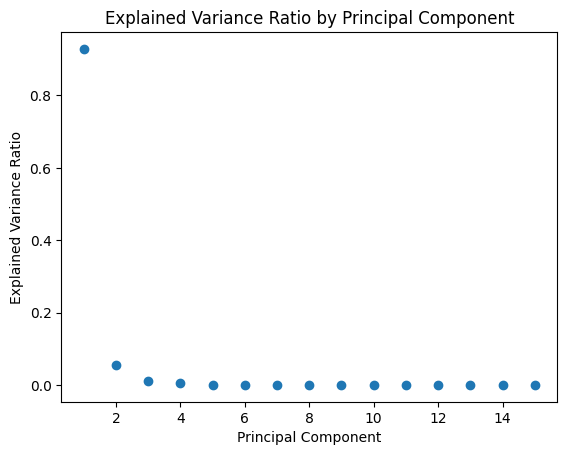

In [10]:
lambdas = pca.explained_variance_ratio_
plt.scatter(range(1, len(lambdas) + 1), lambdas)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Component')
plt.show()

#### Uncomment and run the following cell to project data onto chosen number of principal components:

In [11]:
#pca_data = pca.transform(fitdata)

#### Running ridge regression on the full dataset (fit data + element labels)
Ideally, datasets are broken up into different working electrolytes/element compounds, then modeled appropriately.
Then choose the most optimal combination given the molecule and see if it has any global maximuma for any tuning parameter.

In [12]:
scaler = MinMaxScaler() # introducing a normalizing factor for the data as opposed to centralising, for the paretoset.
# The model still uses centred data and hence has numerical stability
pdata_norm = pdata.iloc[:, 6:]
pdata_norm = fitdata.astype(float)
pdata_norm = pd.DataFrame(
    scaler.fit_transform(pdata_norm),
    columns=pdata_norm.columns,
    index=pdata_norm.index
)

In [13]:
pdata_norm.head()

,max_delta_volume,average_voltage,capacity_grav,capacity_vol,energy_grav,energy_vol,stability_charge,stability_discharge,electrode_density,material_density,working_ion_cost_per_kWh,formation_energy_per_atom,band_gap,energy_density,battery_cost_per_L
0,0.009332,0.195130,0.285702,0.506989,0.184992,0.225721,0.000556,0.000000,0.272025,0.219584,1.0,0.569596,0.000000,0.029980,0.029996
1,0.005352,0.214860,0.257598,0.482412,0.262326,0.311806,0.050627,0.000000,0.287757,0.290084,1.0,0.428265,0.098885,0.137827,0.137840
2,0.001256,0.209491,0.054554,0.231041,0.179270,0.243937,0.007639,0.000000,0.654637,0.187751,1.0,0.521293,0.000000,0.052801,0.052816
3,0.010066,0.179074,0.227903,0.327670,0.122999,0.168767,0.000000,0.056715,0.219584,0.218767,1.0,0.482441,0.000000,0.041336,0.041352
4,0.005164,0.188381,0.606787,0.321579,0.146920,0.197046,0.000000,0.009765,0.073381,0.662461,1.0,0.471405,0.000000,0.005909,0.005925


In [14]:
# front_index = paretoset.paretoset(pdata_norm, sense=["min", "max", "max", "max", "max", "max", "min", "min", "min", "min", "min", "min", "min", "max", "min"])
# # Voltage and capacity alone are to be maximized - band gap, density and even voltage are vague measurements and depend on the application.
# # A heavy duty battery for application like automobile battery is considered.

# fitdata = fitdata.iloc[front_index]
# pdata_front = pdata.iloc[front_index]
# structure_volums = structure_volums.iloc[front_index]
# structure_abc_df = structure_abc_df.iloc[front_index]

In [15]:
pdata.shape # Checking if pareto set removed significant share of data

(5775, 21)

In [70]:
# Get all elements in working_ion and elements columns from pdata
working_ion = pdata["working_ion"]
elements = pdata["elements"]

# Assigning weights to different working ions
working_ion_weight = []
for i in working_ion:
    if i == "Li":
        working_ion_weight.append(0.5)
    elif i == "Na":
        working_ion_weight.append(0.3)
    elif i == "Ca":
        working_ion_weight.append(0.05)
    else:
        working_ion_weight.append(0.1) 
working_ion_weight_test = pd.Series(working_ion_weight)
del working_ion_weight
# print(working_ion_weight_test.shape) 
# print(working_ion_weight_test[2625:2635])
# working_ion_weight_test = working_ion_weight_test.iloc[front_index]
# print(working_ion_weight_test.shape) 
# print(working_ion_weight_test[2625:2635])

#### NEW MODEL: Capacity-based scoring

Gravimetric capacity is taken as the most important parameter for ranking a battery.

#### Implementing the scoring function
Assign labels/Scoring Method- for features: valuable features, grav_capacity, delta_v (for effective cost given density), working ion, elements, nelements, structure, chemical family*


Chemical family is a little difficult to get since it's not on the materials project dataset, but if we first generate the top 100 best materials and cross check with the other dataset, we can include that in our model manually.

In [71]:
def scoring(capacity_g, avg_v, test, structure_v, abc, e_d, b_c):
    capacity_g = capacity_g.to_numpy()
    avg_v = avg_v.to_numpy()
    print(test.head())
    test = test.to_numpy()
    structure_v = structure_v.to_numpy()
    a = abc["a"].to_numpy()
    b = abc["b"].to_numpy()
    c = abc["c"].to_numpy()
    e_d = e_d.to_numpy()
    b_c = b_c.to_numpy()    
    score = test*(capacity_g * 0.4 + avg_v * 0.4 - structure_v * 0.05 + 0.05*a + 0.05*b + 0.05*c + 0.3*e_d - b_c)
    return pd.Series(score)

In [72]:
#battery_score = working_ion_mass + elements_mass*pdata["nelements"]
battery_score = scoring(fitdata["capacity_grav"], fitdata["average_voltage"], working_ion_weight_test, structure_volums, structure_abc_df, pdata["energy_density"], pdata["battery_cost_per_L"])
# print(structure_abc_df)
# print(fitdata.shape)
print(fitdata["capacity_grav"].shape, fitdata["average_voltage"].shape, working_ion_weight_test.shape, structure_volums.shape, structure_abc_df.shape, pdata["energy_density"].shape, pdata["battery_cost_per_L"].shape)
# Testing to see if the model works with a randomly generated sample of fitdata and battery score
fit_train, fit_test, score_train, score_test = train_test_split(fitdata, battery_score, test_size=0.1, random_state=42)

0    0.5
1    0.5
2    0.5
3    0.5
4    0.5
dtype: float64
(5775,) (5775,) (5775,) (5775,) (5775, 3) (5775,) (5775,)


In [73]:
ridge = linear_model.Ridge(alpha=1.0).fit(fit_train, score_train, sample_weight=None)
score_pred = ridge.score(fit_test, score_test)
print(score_pred)

0.959858997939338


In [74]:
print(np.where(battery_score == np.max(battery_score)))
best = np.where(battery_score == np.max(battery_score))[0][0]  #np.min(battery_score) was changed to max(battery_score) to obtain best capacity
print(pdata.iloc[best])
print(np.max(battery_score))
print(working_ion_weight_test.iloc[best])
# print(working_ion_weight_test.iloc[best]*(fitdata["capacity_grav"].iloc[best]*0.4 + fitdata["average_voltage"].iloc[best]*0.4 - structure_volums.iloc[best] * 0.05 + 0.05*structure_abc_df["a"].iloc[best] + 0.05*structure_abc_df["b"].iloc[best] + 0.05*structure_abc_df["c"].iloc[best] + 0.1*pdata["energy_density"].iloc[best] - pdata["battery_cost_per_L"].iloc[best]))

(array([3204]),)
battery_formula              Li1-3Ti2(PO4)3
working_ion                              Li
elements                             Ti,P,O
nelements                               3.0
formula_charge                  LiTi2(PO4)3
formula_discharge              Li3Ti2(PO4)3
max_delta_volume                   0.086321
average_voltage                   33.065771
capacity_grav                    133.516371
capacity_vol                     421.348595
energy_grav                     4414.821755
energy_vol                     13932.216223
stability_charge                   3.516172
stability_discharge                0.074915
electrode_density                  3.155782
material_density                   5.482777
working_ion_cost_per_kWh               10.0
formation_energy_per_atom         -2.067682
band_gap                                  0
energy_density                 13932.216223
battery_cost_per_L               139.322162
Name: 3210, dtype: object
2019.3809987490292
0.5


In [75]:

X = fitdata
y = scoring(fitdata["capacity_grav"], fitdata["average_voltage"], working_ion_weight_test, structure_volums, structure_abc_df, pdata["energy_density"], pdata["battery_cost_per_L"])
y = y.fillna(0)
y = y.astype(float)

0    0.5
1    0.5
2    0.5
3    0.5
4    0.5
dtype: float64


In [76]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", linear_model.Ridge(alpha=1.0))
])

In [77]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []
MAE = []
MSE = []
bestmaterial = []

for train_idx, test_idx in kf.split(X):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    #Find best material in predicted set
    bestmaterial.append(X_test.iloc[np.where(y_pred == np.max(y_pred))[0][0]])
    print(np.max(y_pred))

    r2_scores.append(r2_score(y_test, y_pred))
    MSE.append(mean_squared_error(y_test, y_pred))
    MAE.append(mean_absolute_error(y_test, y_pred))

print("Mean R2:", np.mean(r2_scores))
print("Mean MSE:", np.mean(MSE))
print("Mean MAE:", np.mean(MAE))
print("Best materials in each fold:", type(bestmaterial[0]))
bestmaterial_df = pd.DataFrame(bestmaterial)

1010.9029848972649
2090.1727643298245
756.9721053186371
908.3220010360388
1547.4016226754843
Mean R2: 0.9490600206232218
Mean MSE: 1153.7191354643533
Mean MAE: 17.2125497762914
Best materials in each fold: <class 'pandas.core.series.Series'>


In [78]:
# Finding the equivalent material in the original pdata for each best material in bestmaterial_df by minimizing the difference between each feature of bestmaterial_df and pdata
for i in range(len(bestmaterial)):
    best_material = bestmaterial_df.iloc[i]
    min_diff = float('inf')
    best_match_index = -1
    for j in range(len(pdata)):
        diff = np.sum(np.abs(best_material - pdata.iloc[j, 6:6+len(best_material)]))
        if diff < min_diff:
            min_diff = diff
            best_match_index = j
    print(f"Best material in fold {i+1}:")
    print(pdata.iloc[best_match_index, 0])

Best material in fold 1:
Ca0-2Cr2O5
Best material in fold 2:
Li1-3Ti2(PO4)3
Best material in fold 3:
Li0-2CrWO6
Best material in fold 4:
Li0-1MnF4
Best material in fold 5:
Ca0.25-0.5C
